Importing Libraries

In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import sys

sys.path.append("..")
from data_loader import jobs_data

# Loading... Data

In [82]:
# Copy of the main DataFrame
df = jobs_data.copy()

In [83]:
# Data informations
df.info()
df.sample(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 18 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,yearly_salary_avg
577420,Business Analyst,"Business Analyst, Human Resource","Kuala Lumpur, Federal Territory of Kuala Lumpu...",via Maukerja,None,False,Malaysia,2023-08-19 09:23:27,False,False,Malaysia,None,NaN,NaN,7-eleven Malaysia Sdn Bhd,NaN,None,NaN
108005,Data Scientist,DATA SCIENTIST PYTHON-MACHINE LEARNING EN ALTE...,"Les Lilas, France",via Jobrapido.com,Full-time,False,France,2023-11-30 00:16:49,False,False,France,None,NaN,NaN,OpenClassrooms,"[python, pandas, numpy, scikit-learn, tensorfl...","{'libraries': ['pandas', 'numpy', 'scikit-lear...",NaN
526660,Senior Data Engineer,Senior Data Engineer,"Rotterdam, Netherlands",via LinkedIn,Full-time,False,Netherlands,2023-03-16 11:34:07,True,False,Netherlands,None,NaN,NaN,Shell,"[shell, express, excel, flow]","{'analyst_tools': ['excel'], 'other': ['flow']...",NaN


Cleaning Data

In [84]:
# Cleaning the date column
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

# Visualizations

What countries does the dataset depend on?

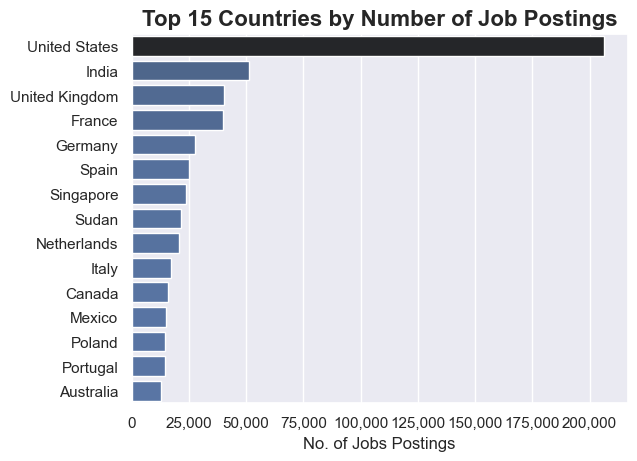

In [85]:
countries = df['job_country'].value_counts().nlargest(15).to_frame()

sns.set_theme()
sns.barplot(data=countries, x='count', y=countries.index, hue='count', legend=False, palette='dark:b_r')

plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: format(int(x), ",")))

plt.title('Top 15 Countries by Number of Job Postings', fontweight='bold', size=16)
plt.ylabel('')
plt.xlabel('No. of Jobs Postings')

plt.savefig("../visuals/job_postings_by_country.png", dpi=150, bbox_inches="tight")
plt.show()

What jobs does the dataset depend on?

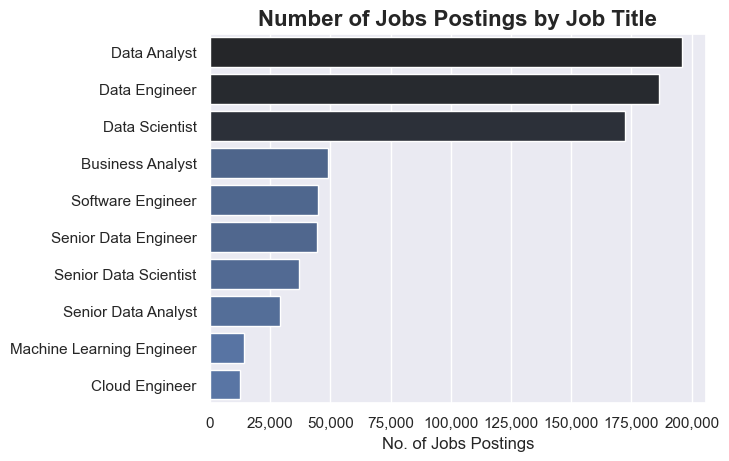

In [86]:
jobs = df['job_title_short'].value_counts().to_frame()

sns.set_theme()
sns.barplot(data=jobs, x='count', y=jobs.index, hue='count', legend=False, palette='dark:b_r')

plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: format(int(x), ",")))

plt.title('Number of Jobs Postings by Job Title', fontweight='bold', size=16)
plt.ylabel('')
plt.xlabel('No. of Jobs Postings')

plt.savefig("../visuals/total_job_postings.png", dpi=150, bbox_inches="tight")
plt.show()

What is the date of the dataset?

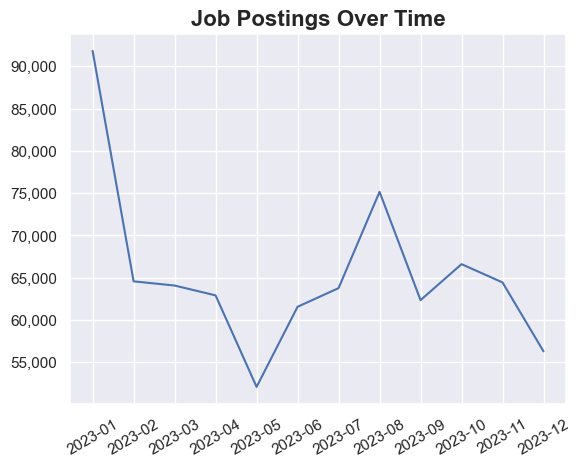

In [87]:
date = df['job_posted_date'].dt.strftime('%Y-%m').value_counts().to_frame()
date.reset_index(inplace=True)
date.sort_values(by='job_posted_date', inplace=True)

sns.set_theme()
sns.lineplot(data=date, x='job_posted_date', y='count')

plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda y, pos: format(int(y), ",")))
plt.xticks(rotation=30)

plt.title('Job Postings Over Time', fontweight='bold', size=16)
plt.ylabel('')
plt.xlabel('')

plt.savefig("../visuals/job_postings_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

Yearly Salary VS Hourly Salary

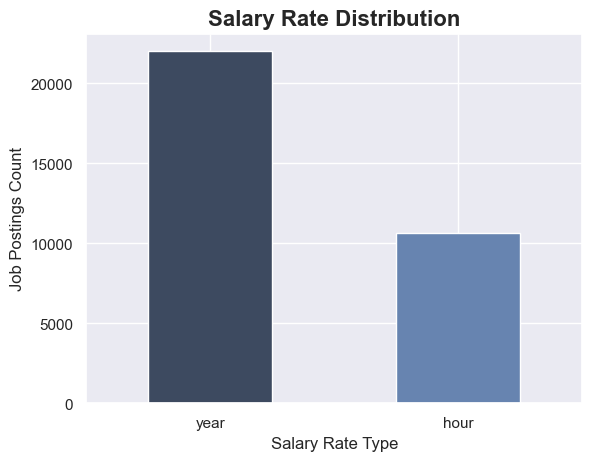

Note: 95.8% has no valid salary rate


In [88]:
salary_rate = df[(df['salary_rate'] == 'year') | (df['salary_rate'] == 'hour')]['salary_rate'].value_counts()

salary_rate.plot(
    kind='bar',
    color=["#3d4a60",'#6784b0']
)

plt.title('Salary Rate Distribution', fontweight='bold', size=16)
plt.xlabel('Salary Rate Type')
plt.ylabel('Job Postings Count')
plt.xticks(rotation=0)

plt.savefig("../visuals/salary_rate_distribution.png", dpi=150, bbox_inches="tight")
plt.show()



total = len(df)
valid = df['salary_rate'].isin(['year', 'hour']).sum()
missing = total - valid

print(f"Note: {(missing / total) * 100:.1f}% has no valid salary rate")